# Vega spectrum and UBVRI filter bandpasses

Plot of the spectrum of Vega and the standard UBVRI filter bandpasses,
showing the part of the spectrum covered by each filter.  Vega is the
zero point of the stellar magnitude system.

The Vega spectrum is from the [HST CALSPEC database](https://www.stsci.edu/hst/instrumentation/reference-data-for-calibration-and-tools/astronomical-catalogs/calspec).

In [8]:
%matplotlib inline

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

from astropy.io import fits

from scipy import interpolate

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Figure Filename

`figName` sets the figure filename of the form `Fig<chapterNum>_<figNum>`, the figure number may also 
include a lowercase  letter for a subfigure (e.g., Fig1_2a).  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [9]:
aspWidth = 16
aspHeight = 9

figName = f'Vega_{int(aspWidth)}x{int(aspHeight)}' 

aspect = aspWidth/aspHeight

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
#axisFontSize = np.rint(axisFontSize/scaleFac)
#labelFontSize = np.rint(labelFontSize/scaleFac)

# Plot filename

plotFile = f'{figName}.{figFmt}'

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Vega spectrum



In [10]:
# calstis vega data, fluxes in cgs erg s-1 cm-2 A-1.

vegaFile = 'alpha_lyr_stis_011.fits'
hdu = fits.open(vegaFile)
data = hdu[1].data

vegaLam = np.array(data['wavelength'])/10.0 # convert to nm
vegaFlam = np.array(data['flux'])*1.0e8 # convert to arbitrary units


## Johnson-Kron-Cousins filter bandpasses


In [11]:
bands = ['U','B','V','Rc','Ic']
filterDir = 'UBVRI'
filtColor = {'U':'purple','B':'blue','V':'green','Rc':'#bb0000','Ic':'black'}

filtLam = {}
filtTrans = {}
for band in bands:
    filterFile = f'{filterDir}/JKC_{band}.txt'
    filtData = pd.read_csv(filterFile,sep=r'\s+',comment='#',header=None)
    flam = np.array(filtData[0])
    trans = np.array(filtData[1])
    newLam = np.linspace(flam[0],flam[-1],501) # resample/smooth
    fspl = interpolate.splrep(flam,trans)
    filtLam[band] = newLam
    filtTrans[band] = interpolate.splev(newLam,fspl)


## Physical constants

CODATA2018 values from NIST

In [12]:
c = 299792458. # m/s
h = 6.62607015e-34 # J s
k = 1.380649e-23 # J/K

G = 6.67530e-11 # kg^-1 m^3 s^-2
sigSB = 5.670374419e-8 # W m^-2 K^-4
m_p = 1.67262193269e-27 # kg
m_e = 9.1093837015e-31 # kg
eV2J = 1.602176634e-19 # J/eV

b1 = 2.897771955e-3 # m K 

### Vega Spectrum

Plot the spectrum of vega in scaled F$_\lambda$ flux units versus wavelength in nanometers.


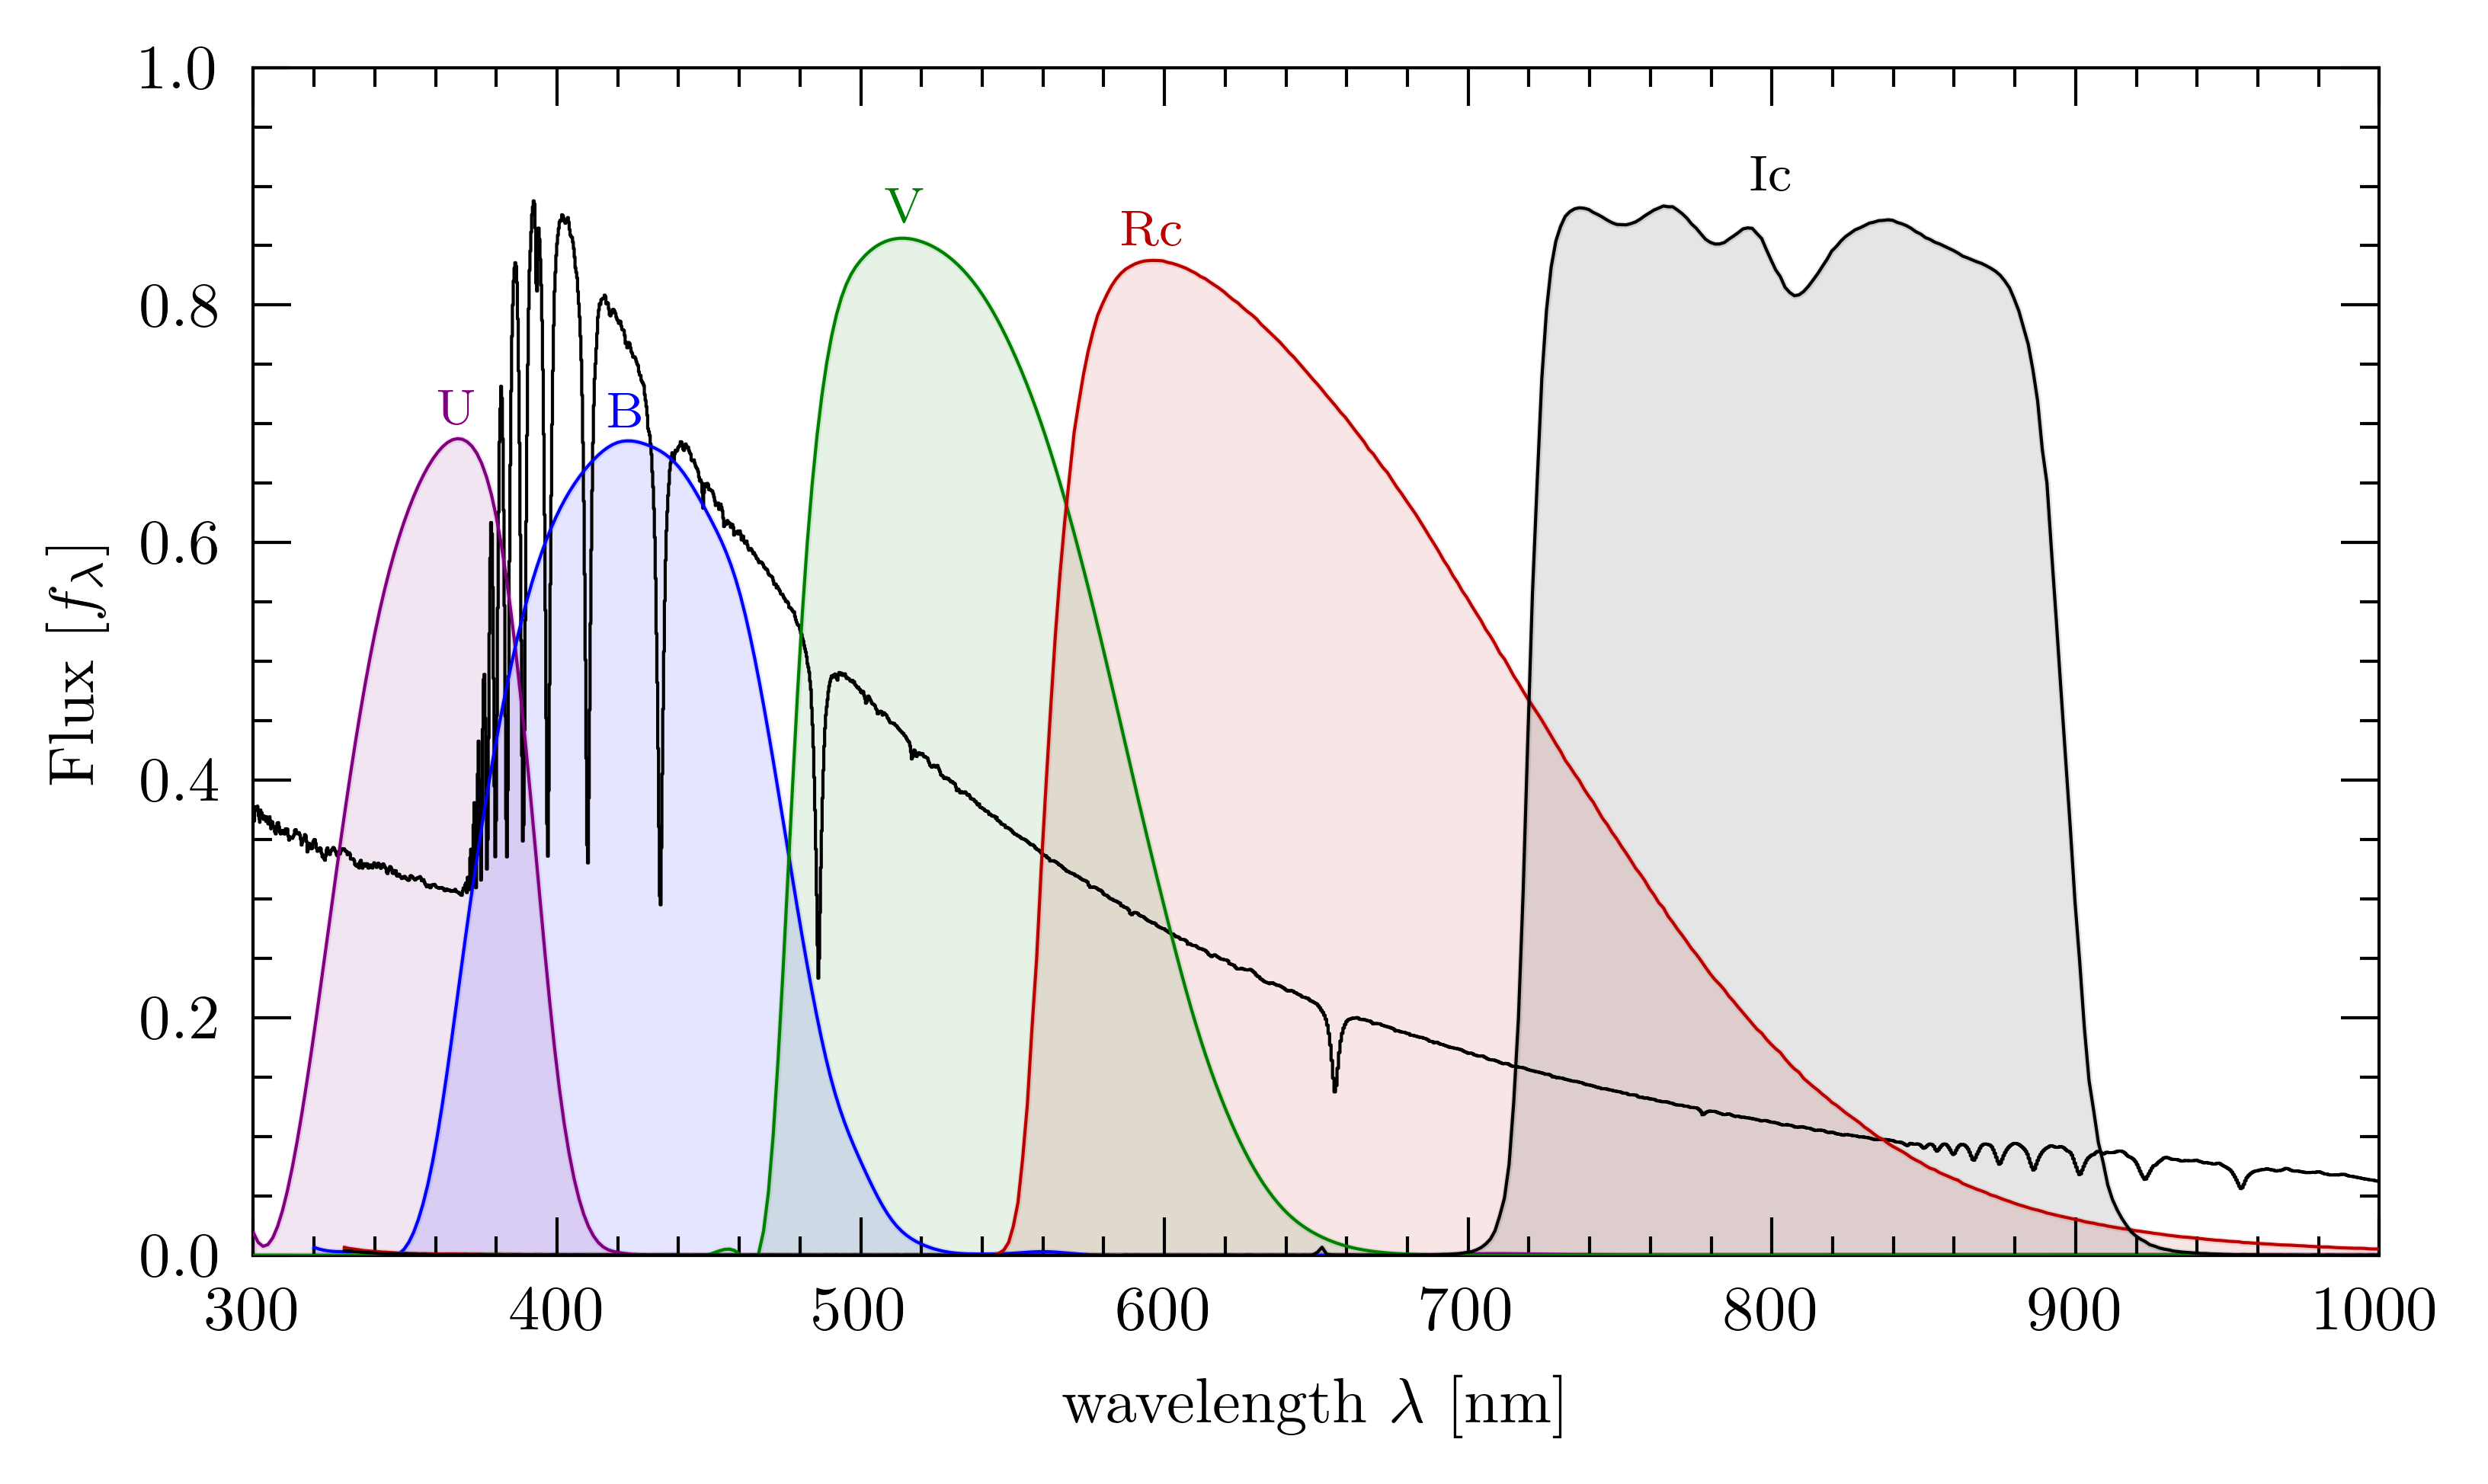

In [13]:

# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

xMin = 300.0 # nm
xMax = 1000.0 # 750.0

yMin = 0.0
yMax = 1.0 # 1.1*np.max(vegaFlam)

ax.set_xlim(xMin,xMax)
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_minor_locator(MultipleLocator(20))
ax.set_xlabel(r'wavelength $\lambda$ [nm]',fontsize=axisFontSize)

ax.set_ylim(yMin,yMax)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#ax.set_ylabel(r'$f_\lambda$ [W m$^{-2}$ nm$^{-1}$]',fontsize=axisFontSize)
ax.set_ylabel(r'Flux [$f_\lambda$]',fontsize=axisFontSize)
#ax.set_ylabel(r'Brightness',fontsize=axisFontSize)
              
ax.step(vegaLam,vegaFlam,'-',color='black',lw=0.5,zorder=9,label='Vega spectrum')

# plot filter bandpasses

for band in bands:
    ax.plot(filtLam[band],filtTrans[band],'-',color=filtColor[band],lw=0.5,zorder=10)
    ax.fill_between(filtLam[band],filtTrans[band],ec=filtColor[band],color=filtColor[band],alpha=0.1)
    iMax = np.argmax(filtTrans[band])
    if band == 'Ic':
        xLab = 800
    else:
        xLab = filtLam[band][iMax]
    yLab = 1.005*filtTrans[band][iMax]
    ax.text(xLab,yLab,band,color=filtColor[band],va='bottom',ha='center',fontsize=labelFontSize)
    
plotFile = 'Vega_UBVRcIc_16x9.png'
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()